In [1]:
import pandas as pd
import numpy as np

In [2]:
df_task1 = pd.read_excel(r"/Users/sandro_diakourakis/Documents/GitHub/-SLP_PStA_Team_Drzimalla_Diakourakis/data/task1/sand_task_1.xlsx")
df_task2 = pd.read_excel(r"/Users/sandro_diakourakis/Documents/GitHub/-SLP_PStA_Team_Drzimalla_Diakourakis/data/task2/sand_task_2.xlsx")

In [3]:
df_task1.head()

,ID,Age,Sex,Class
0,ID000,80,M,5
1,ID001,61,F,5
2,ID002,51,F,4
3,ID003,59,M,3
4,ID005,80,F,5


In [4]:
df_task2.head()

,ID,Age,Sex,Months,ALSFRS--R_start,ALSFRS--R_end
0,ID002,51,F,10,4,4
1,ID003,59,M,11,3,3
2,ID007,72,M,6,3,1
3,ID009,51,F,11,3,3
4,ID010,57,M,10,4,3


In [5]:
# TODO Funktionen aus preprocessing hier einfügen und analysieren, was passiert
# siehe Claude


## Explorative Datenanalyse

SAND CHALLENGE - TASK 1: EXPLORATIVE DATENANALYSE

[1] DATEN LADEN
--------------------------------------------------------------------------------
✓ Excel-Datei geladen: /Users/sandro_diakourakis/Documents/GitHub/-SLP_PStA_Team_Drzimalla_Diakourakis/data/task1/sand_task_1.xlsx
  Verfügbare Sheets: ['SAND - TRAINING set - Task 1', 'Training Baseline - Task 1', 'Validation Baseline - Task 1']

✓ Training Set geladen: 272 Samples
✓ Baseline Training Set: 219 Samples
✓ Baseline Validation Set: 53 Samples

[2] GRUNDLEGENDE DATENÜBERSICHT
--------------------------------------------------------------------------------

📊 Erste 5 Zeilen:
      ID  Age Sex  Class
0  ID000   80   M      5
1  ID001   61   F      5
2  ID002   51   F      4
3  ID003   59   M      3
4  ID005   80   F      5

📊 Datentypen und fehlende Werte:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 


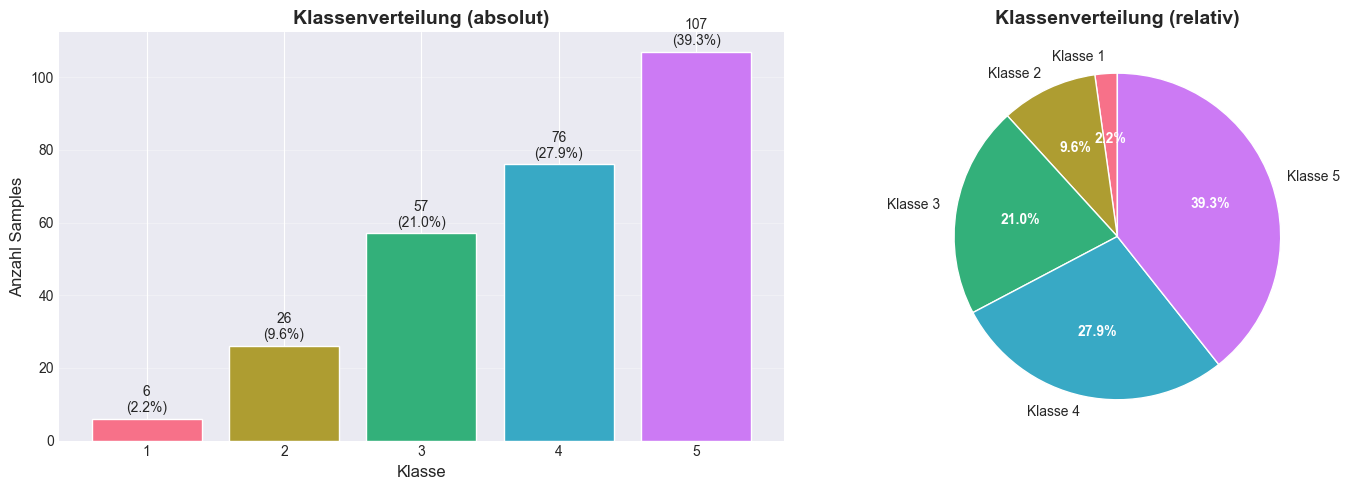


⚠️ IMBALANCE-WARNUNG:
  Größte Klasse (5): 39.3%
  Kleinste Klasse (1): 2.2%
  Imbalance Ratio: 17.8:1

[4] DEMOGRAFISCHE ANALYSE
--------------------------------------------------------------------------------

👥 Geschlechterverteilung:
Sex
M    153
F    119
Name: count, dtype: int64

Männlich: 153 (56.2%)
Weiblich: 119 (43.8%)

👥 Geschlechterverteilung pro Klasse:
Sex       F     M
Class            
1      66.7  33.3
2      57.7  42.3
3      36.8  63.2
4      36.8  63.2
5      47.7  52.3

📅 Altersstatistiken:
count    272.0
mean      63.5
std       11.3
min       23.0
25%       56.8
50%       64.5
75%       72.0
max       89.0
Name: Age, dtype: float64


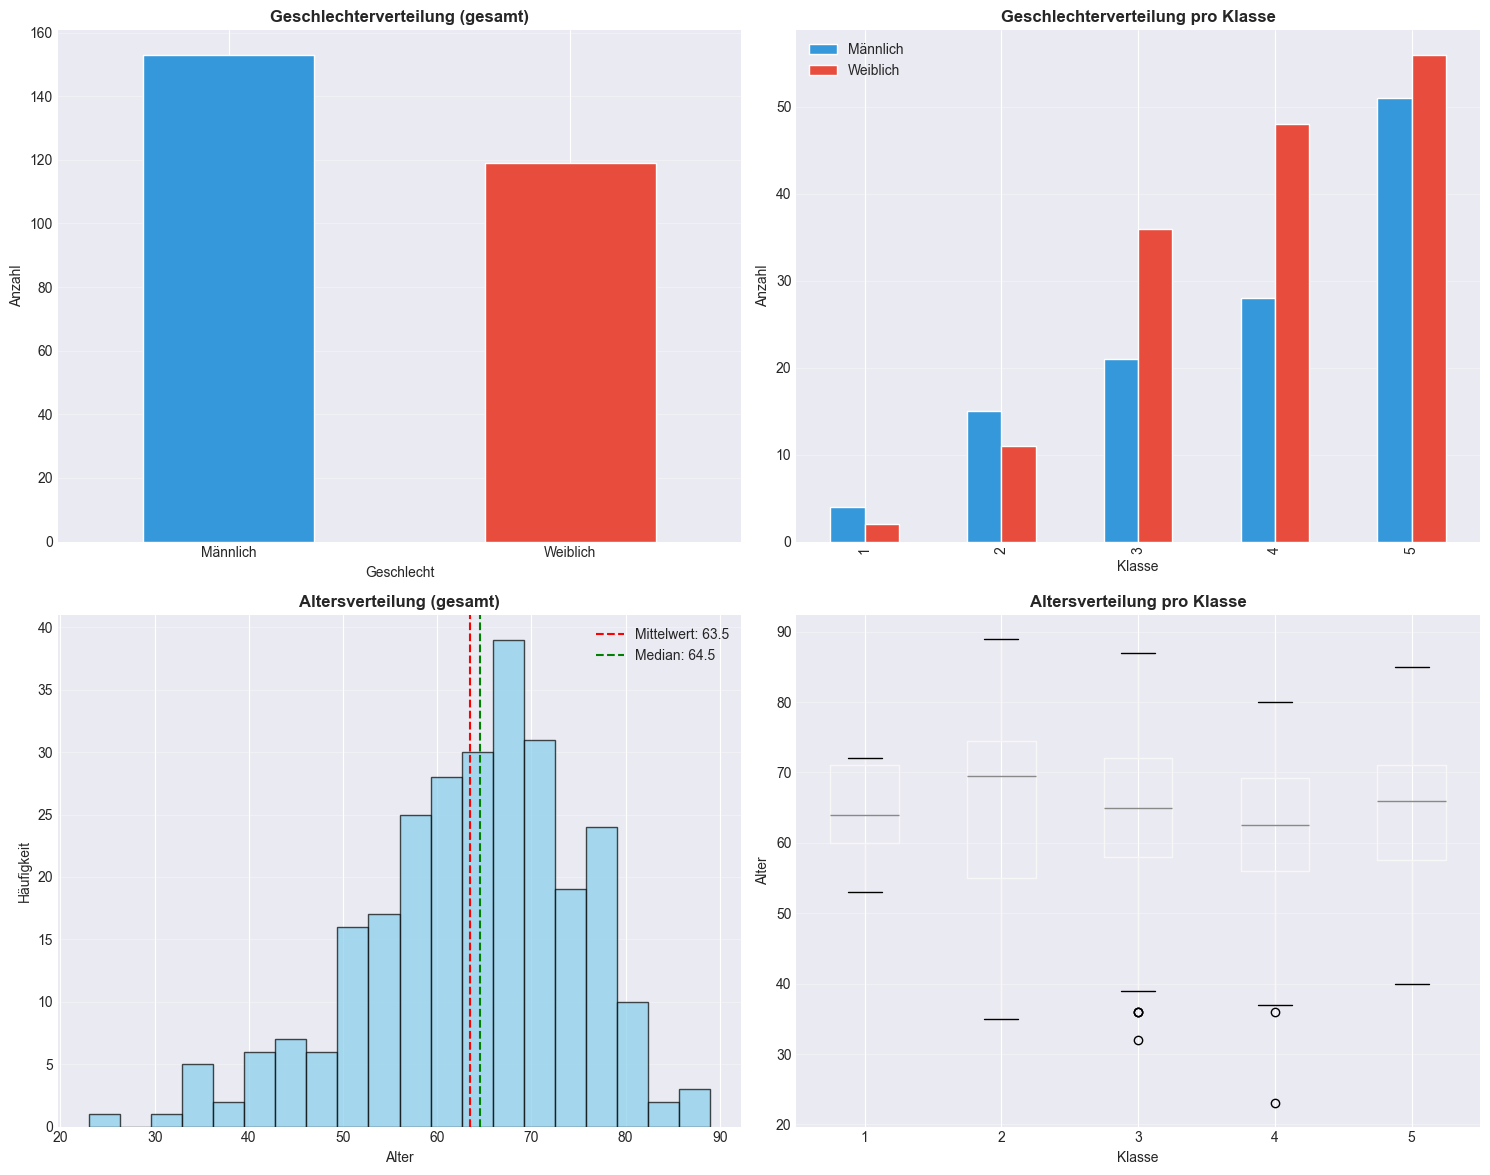


📅 Altersstatistik pro Klasse:
       count  mean   std  min  max
Class                             
1          6  64.2   7.7   53   72
2         26  65.4  13.5   35   89
3         57  63.9  12.8   32   87
4         76  61.5  11.1   23   80
5        107  64.2  10.1   40   85

[5] AUDIO-DATEI ANALYSE
--------------------------------------------------------------------------------

💡 Beispielanalyse für verschiedene Patienten

📊 Analysiere 5 Beispielpatienten (je 1 pro Klasse):


🔊 Analysiere Patient: ID077
   Klasse 1: Schwer
   ✓ 8 Audio-Dateien gefunden

   ✓ Vokal /a/: 3.72s, Energy: 0.0473
   ✓ Vokal /e/: 2.24s, Energy: 0.0561
   ✓ Vokal /i/: 2.84s, Energy: 0.0927
   ✓ Vokal /o/: 3.72s, Energy: 0.0514
   ✓ Vokal /u/: 3.60s, Energy: 0.0910
   ✓ Silbe /pa/: 6.64s, Energy: 0.0529
   ✓ Silbe /ta/: 6.08s, Energy: 0.0443
   ✓ Silbe /ka/: 7.24s, Energy: 0.0545


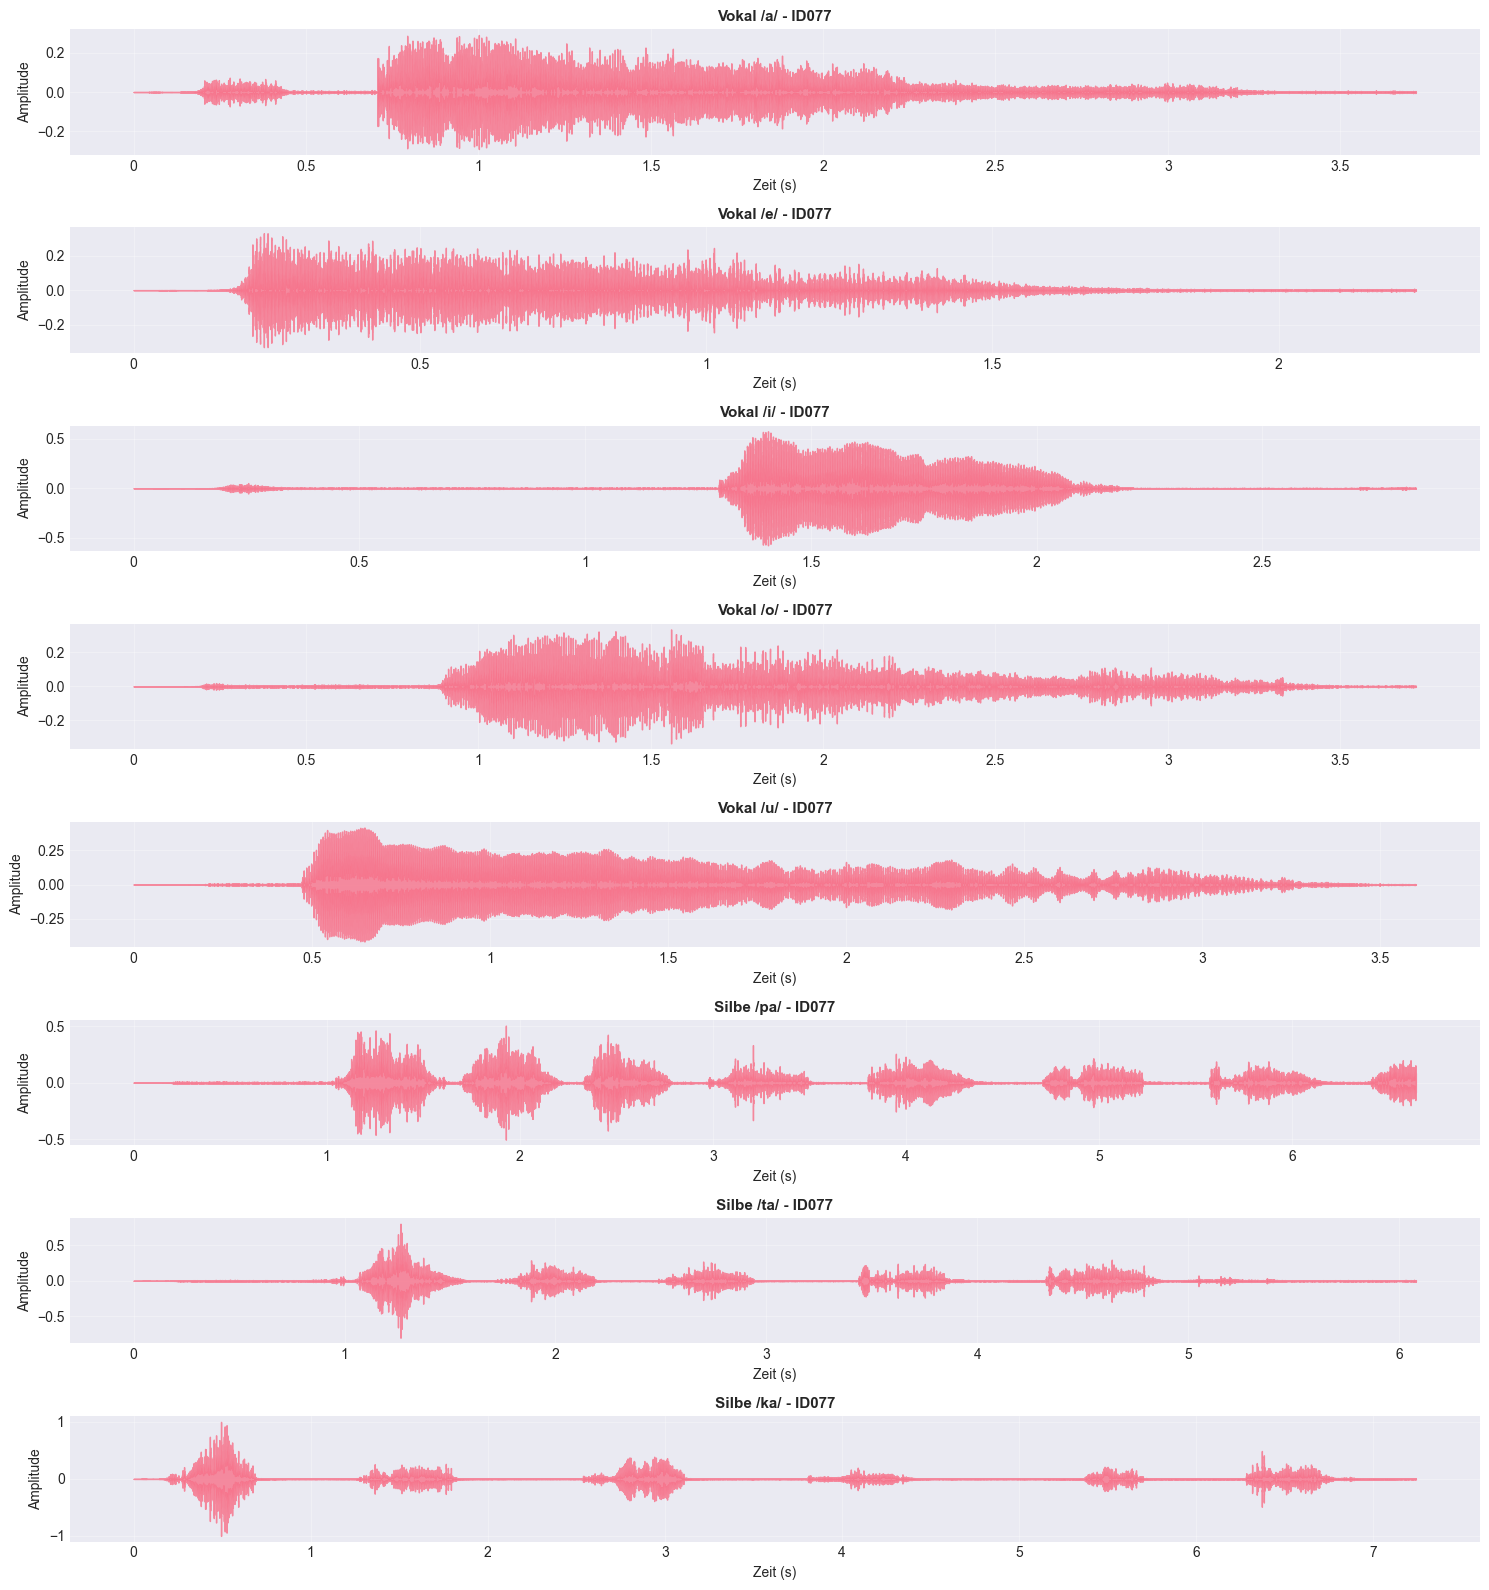

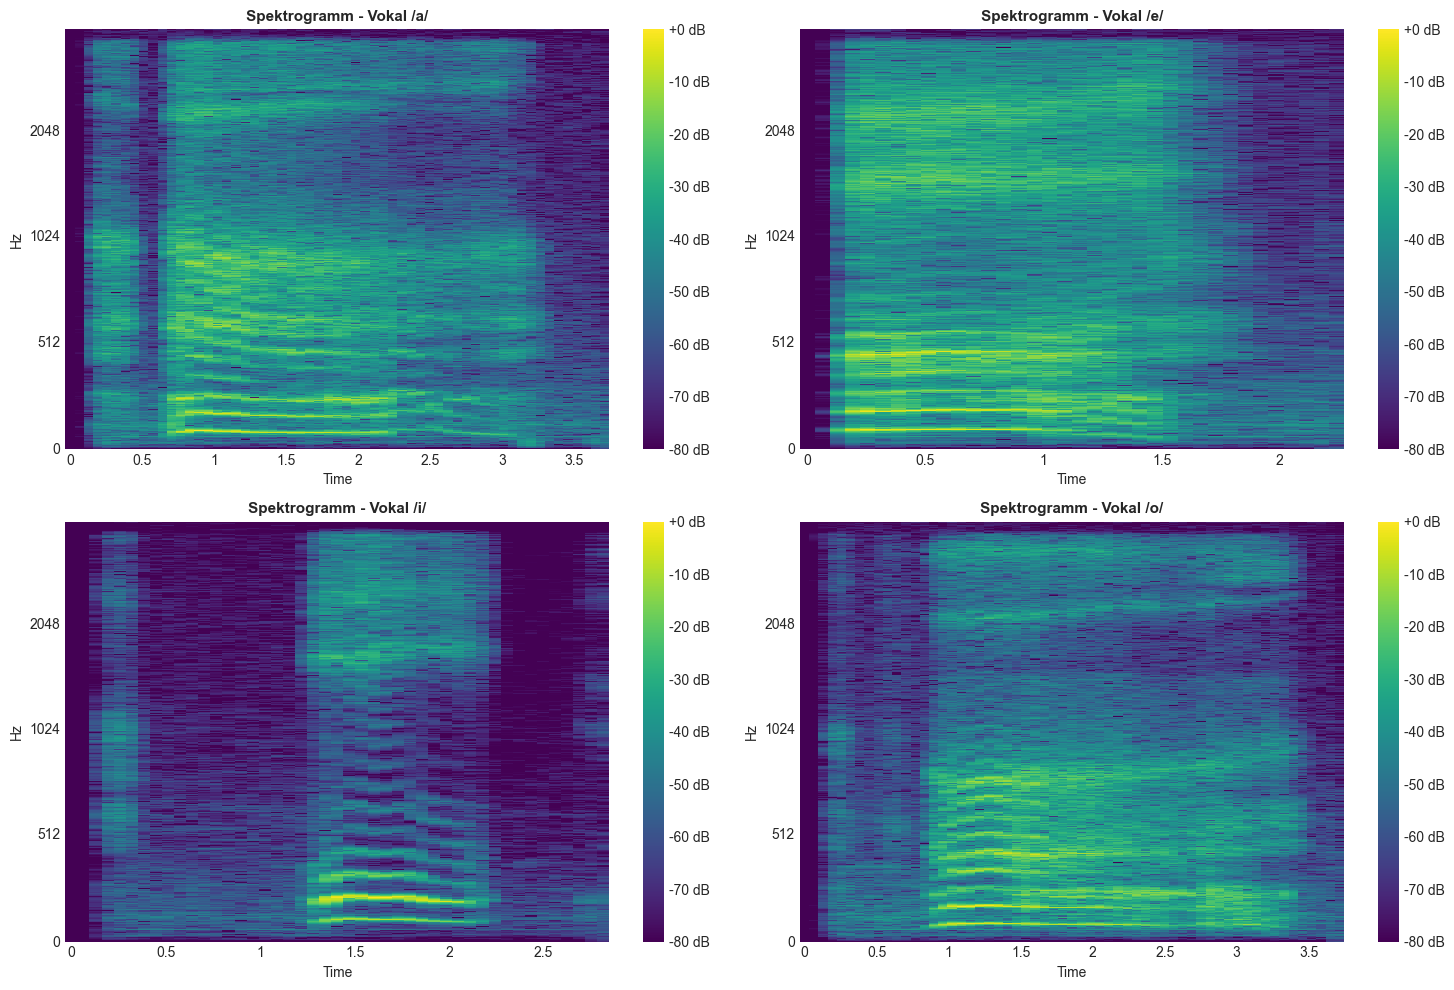


--------------------------------------------------------------------------------

🔊 Analysiere Patient: ID017
   Klasse 2: Moderat
   ✓ 8 Audio-Dateien gefunden

   ✓ Vokal /a/: 6.72s, Energy: 0.0694
   ✓ Vokal /e/: 5.71s, Energy: 0.0732
   ✓ Vokal /i/: 6.02s, Energy: 0.0767
   ✓ Vokal /o/: 5.58s, Energy: 0.0709
   ✓ Vokal /u/: 5.42s, Energy: 0.0732
   ✓ Silbe /pa/: 5.41s, Energy: 0.0763
   ✓ Silbe /ta/: 5.26s, Energy: 0.0662
   ✓ Silbe /ka/: 4.02s, Energy: 0.0513


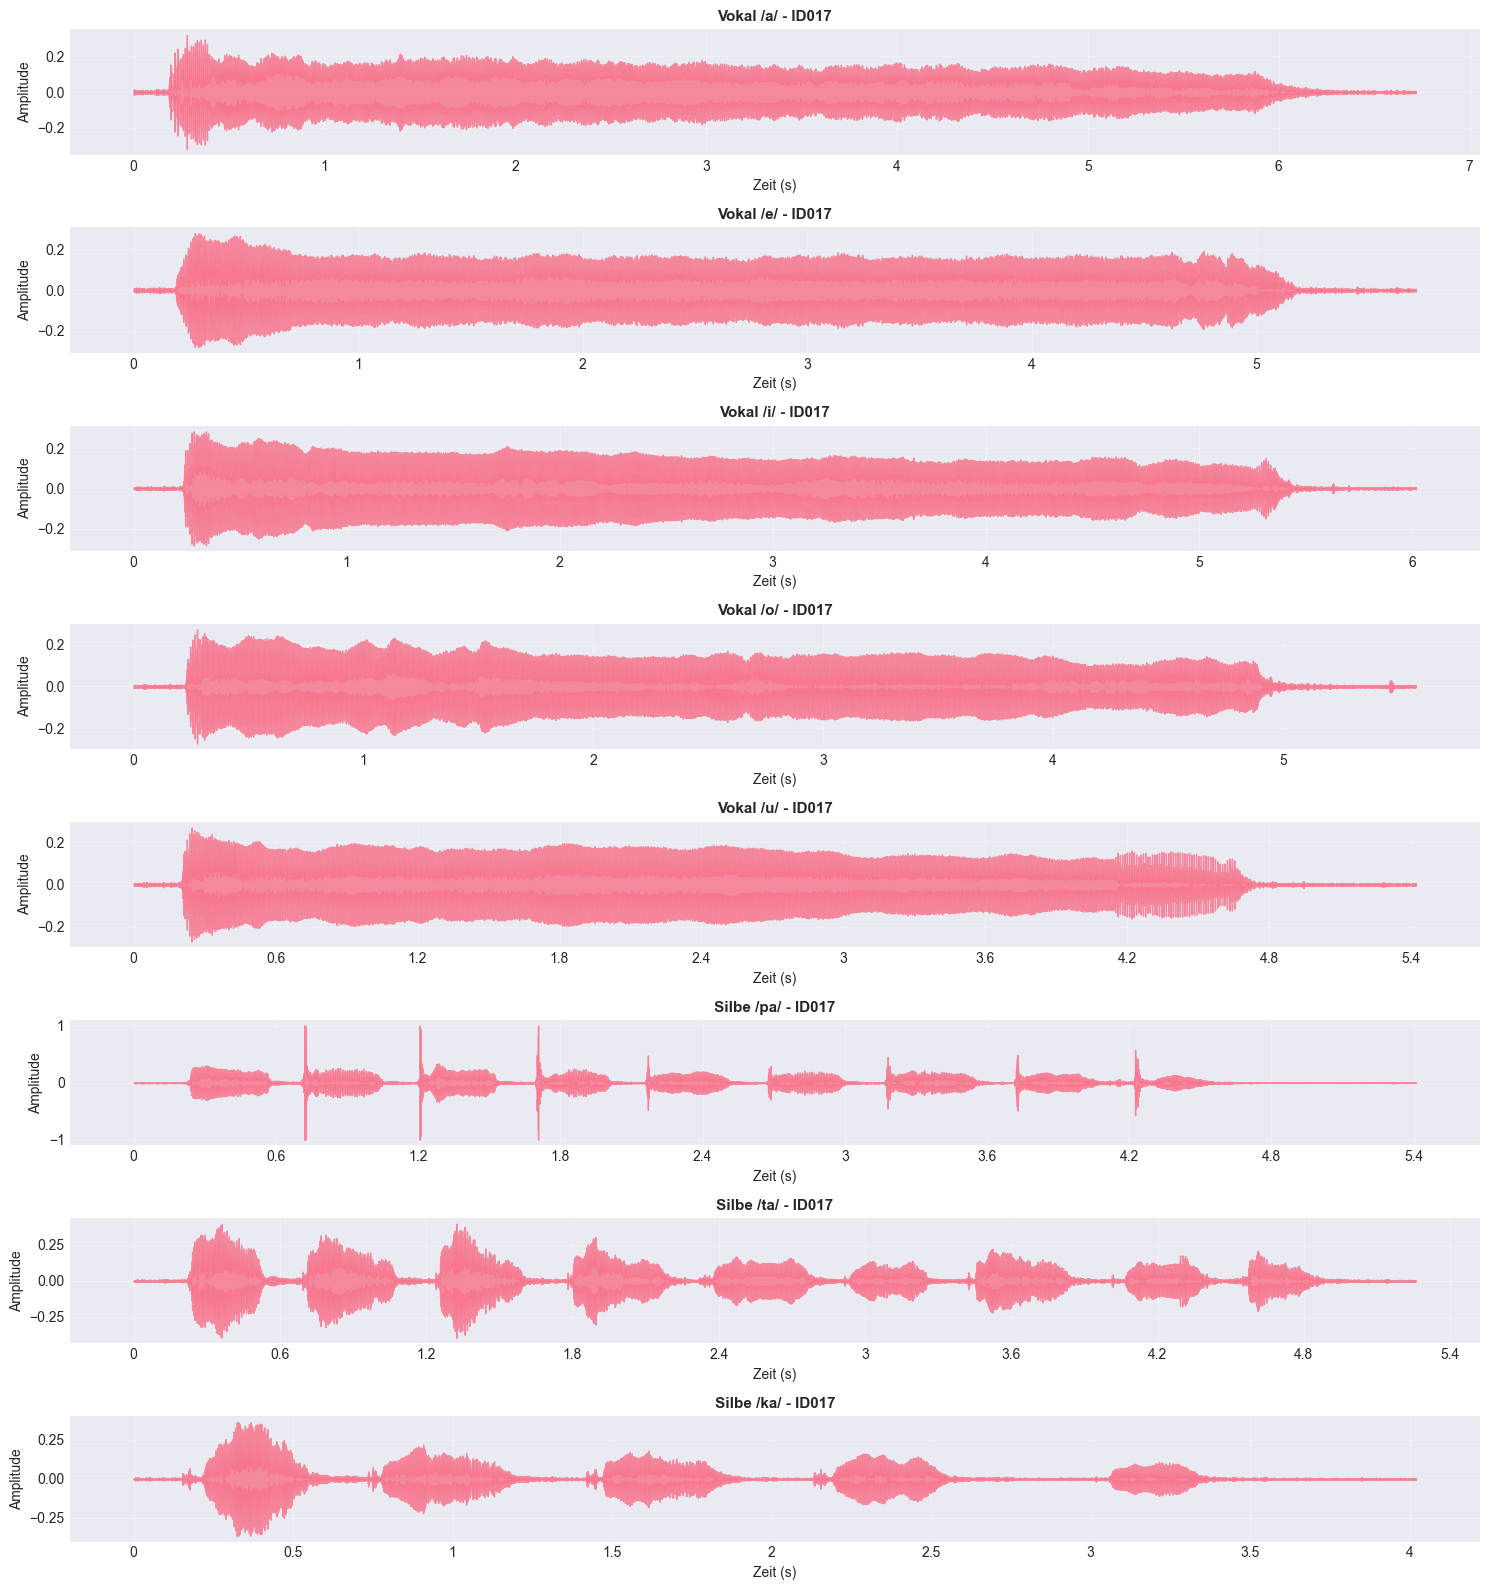

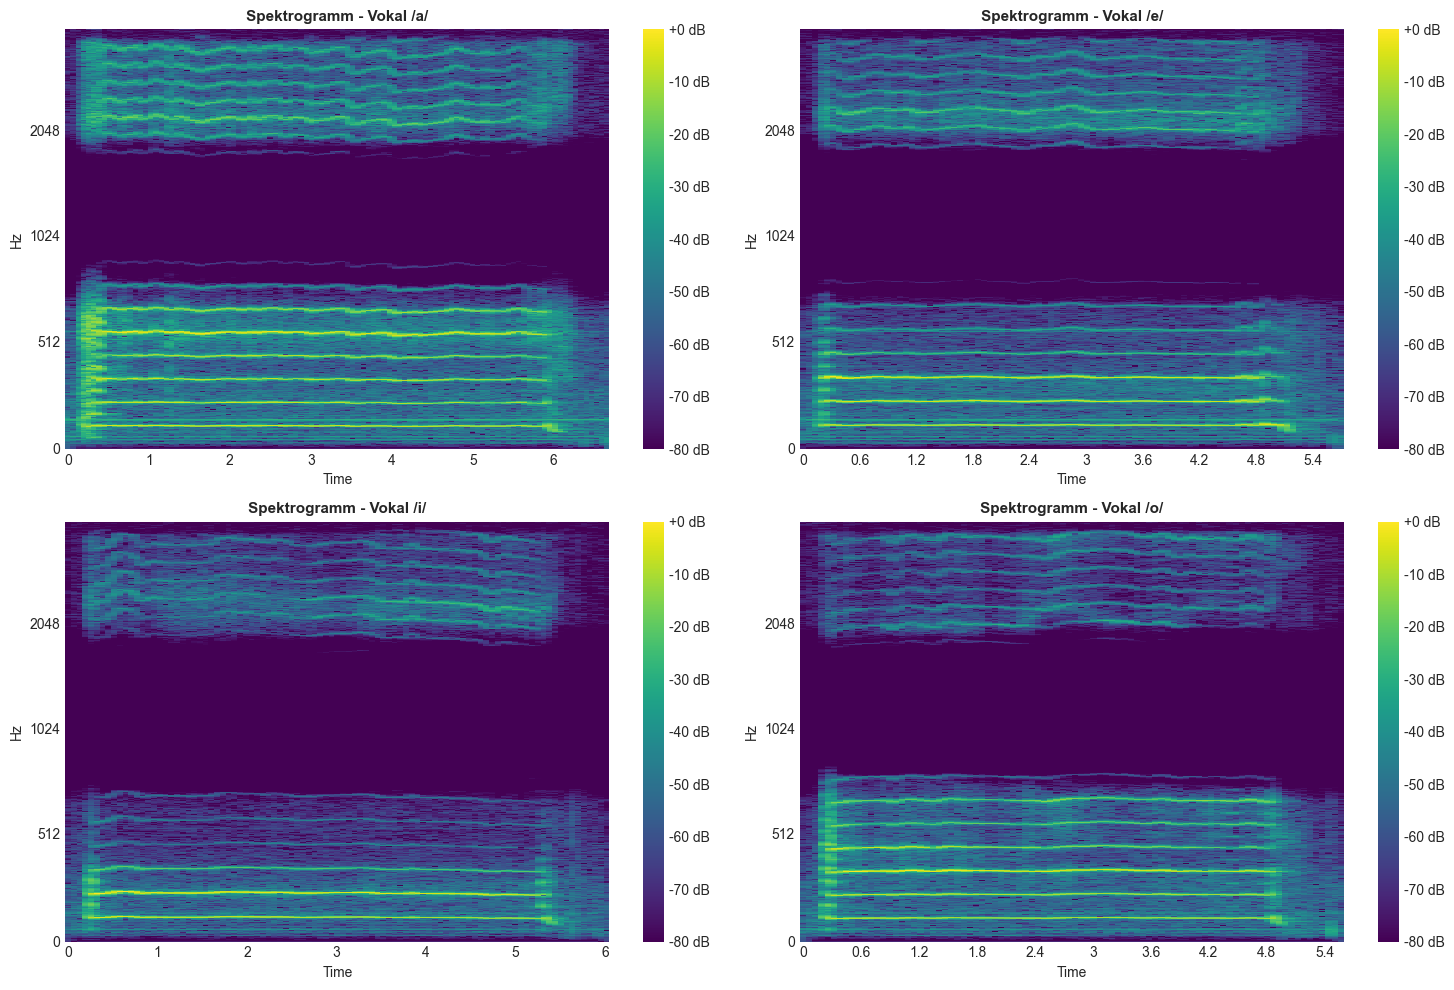


--------------------------------------------------------------------------------

💡 Tipp: Passe die Anzahl der analysierten Patienten an, indem du
   example_patients[:2] zu example_patients[:5] änderst

ZUSAMMENFASSUNG



In [11]:
# SAND Challenge - Task 1: Explorative Datenanalyse
# Multi-Class Classification für Dysarthrie-Schweregrad bei ALS-Patienten

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import librosa
import librosa.display
import warnings
warnings.filterwarnings('ignore')

# Plotting Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 80)
print("SAND CHALLENGE - TASK 1: EXPLORATIVE DATENANALYSE")
print("=" * 80)

# ============================================================================
# 1. DATEN LADEN
# ============================================================================
print("\n[1] DATEN LADEN")
print("-" * 80)

# Pfade anpassen - bitte deine lokalen Pfade hier eintragen
TRAIN_FILE = "/Users/sandro_diakourakis/Documents/GitHub/-SLP_PStA_Team_Drzimalla_Diakourakis/data/task1/sand_task_1.xlsx"  # Pfad zu deiner Excel-Datei
AUDIO_PATH = "/Users/sandro_diakourakis/Documents/GitHub/-SLP_PStA_Team_Drzimalla_Diakourakis/data/task1/training"  # Pfad zu deinen Audio-Dateien

try:
    # Alle Sheets laden
    xl_file = pd.ExcelFile(TRAIN_FILE)
    print(f"✓ Excel-Datei geladen: {TRAIN_FILE}")
    print(f"  Verfügbare Sheets: {xl_file.sheet_names}\n")

    # Training Set laden
    df_train = pd.read_excel(TRAIN_FILE, sheet_name='SAND - TRAINING set - Task 1')
    df_baseline_train = pd.read_excel(TRAIN_FILE, sheet_name='Training Baseline - Task 1')
    df_baseline_val = pd.read_excel(TRAIN_FILE, sheet_name='Validation Baseline - Task 1')

    print(f"✓ Training Set geladen: {len(df_train)} Samples")
    print(f"✓ Baseline Training Set: {len(df_baseline_train)} Samples")
    print(f"✓ Baseline Validation Set: {len(df_baseline_val)} Samples")

except FileNotFoundError:
    print("❌ Datei nicht gefunden! Bitte Pfad anpassen.")
    df_train = None

# ============================================================================
# 2. GRUNDLEGENDE DATENÜBERSICHT
# ============================================================================
if df_train is not None:
    print("\n[2] GRUNDLEGENDE DATENÜBERSICHT")
    print("-" * 80)

    print("\n📊 Erste 5 Zeilen:")
    print(df_train.head())

    print("\n📊 Datentypen und fehlende Werte:")
    print(df_train.info())

    print("\n📊 Statistische Zusammenfassung:")
    print(df_train.describe())

    print("\n📊 Fehlende Werte pro Spalte:")
    print(df_train.isnull().sum())

# ============================================================================
# 3. KLASSENVERTEILUNG ANALYSIEREN
# ============================================================================
if df_train is not None:
    print("\n[3] KLASSENVERTEILUNG")
    print("-" * 80)

    # Klassenverteilung berechnen
    class_counts = df_train['Class'].value_counts().sort_index()
    class_percentages = df_train['Class'].value_counts(normalize=True).sort_index() * 100

    print("\n📈 Absolute und relative Häufigkeiten:")
    class_df = pd.DataFrame({
        'Anzahl': class_counts,
        'Prozent': class_percentages.round(2)
    })
    class_df.index.name = 'Klasse'
    print(class_df)

    # Klassenbezeichnungen
    class_labels = {
        1: 'Schwere Dysarthrie',
        2: 'Moderate Dysarthrie',
        3: 'Leichte Dysarthrie',
        4: 'Keine Dysarthrie (ALS)',
        5: 'Gesund'
    }

    # Visualisierung
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Balkendiagramm
    ax1 = axes[0]
    bars = ax1.bar(class_counts.index, class_counts.values, color=sns.color_palette("husl", 5))
    ax1.set_xlabel('Klasse', fontsize=12)
    ax1.set_ylabel('Anzahl Samples', fontsize=12)
    ax1.set_title('Klassenverteilung (absolut)', fontsize=14, fontweight='bold')
    ax1.set_xticks(range(1, 6))
    ax1.grid(axis='y', alpha=0.3)

    # Werte auf Balken
    for i, (bar, count) in enumerate(zip(bars, class_counts.values)):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{count}\n({class_percentages.iloc[i]:.1f}%)',
                ha='center', va='bottom', fontsize=10)

    # Kreisdiagramm
    ax2 = axes[1]
    colors = sns.color_palette("husl", 5)
    wedges, texts, autotexts = ax2.pie(class_counts.values,
                                         labels=[f'Klasse {i}' for i in class_counts.index],
                                         autopct='%1.1f%%',
                                         colors=colors,
                                         startangle=90)
    ax2.set_title('Klassenverteilung (relativ)', fontsize=14, fontweight='bold')

    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')

    plt.tight_layout()
    plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n⚠️ IMBALANCE-WARNUNG:")
    print(f"  Größte Klasse (5): {class_percentages.iloc[-1]:.1f}%")
    print(f"  Kleinste Klasse (1): {class_percentages.iloc[0]:.1f}%")
    print(f"  Imbalance Ratio: {class_percentages.iloc[-1] / class_percentages.iloc[0]:.1f}:1")

# ============================================================================
# 4. DEMOGRAFISCHE ANALYSE
# ============================================================================
if df_train is not None:
    print("\n[4] DEMOGRAFISCHE ANALYSE")
    print("-" * 80)

    # Geschlechterverteilung
    print("\n👥 Geschlechterverteilung:")
    sex_dist = df_train['Sex'].value_counts()
    print(sex_dist)
    print(f"\nMännlich: {sex_dist.get('M', 0)} ({sex_dist.get('M', 0)/len(df_train)*100:.1f}%)")
    print(f"Weiblich: {sex_dist.get('F', 0)} ({sex_dist.get('F', 0)/len(df_train)*100:.1f}%)")

    # Geschlechterverteilung pro Klasse
    print("\n👥 Geschlechterverteilung pro Klasse:")
    sex_class = pd.crosstab(df_train['Class'], df_train['Sex'], normalize='index') * 100
    print(sex_class.round(1))

    # Altersverteilung
    print("\n📅 Altersstatistiken:")
    print(df_train['Age'].describe().round(1))

    # Visualisierung
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Geschlechterverteilung gesamt
    ax1 = axes[0, 0]
    sex_dist.plot(kind='bar', ax=ax1, color=['#3498db', '#e74c3c'])
    ax1.set_title('Geschlechterverteilung (gesamt)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Geschlecht')
    ax1.set_ylabel('Anzahl')
    ax1.set_xticklabels(['Männlich', 'Weiblich'], rotation=0)
    ax1.grid(axis='y', alpha=0.3)

    # Geschlechterverteilung pro Klasse
    ax2 = axes[0, 1]
    sex_class_counts = pd.crosstab(df_train['Class'], df_train['Sex'])
    sex_class_counts.plot(kind='bar', ax=ax2, color=['#3498db', '#e74c3c'])
    ax2.set_title('Geschlechterverteilung pro Klasse', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Klasse')
    ax2.set_ylabel('Anzahl')
    ax2.legend(['Männlich', 'Weiblich'])
    ax2.grid(axis='y', alpha=0.3)

    # Altersverteilung (Histogram)
    ax3 = axes[1, 0]
    ax3.hist(df_train['Age'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    ax3.axvline(df_train['Age'].mean(), color='red', linestyle='--',
                label=f'Mittelwert: {df_train["Age"].mean():.1f}')
    ax3.axvline(df_train['Age'].median(), color='green', linestyle='--',
                label=f'Median: {df_train["Age"].median():.1f}')
    ax3.set_title('Altersverteilung (gesamt)', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Alter')
    ax3.set_ylabel('Häufigkeit')
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)

    # Altersverteilung pro Klasse (Boxplot)
    ax4 = axes[1, 1]
    df_train.boxplot(column='Age', by='Class', ax=ax4)
    ax4.set_title('Altersverteilung pro Klasse', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Klasse')
    ax4.set_ylabel('Alter')
    plt.suptitle('')  # Entfernt automatischen Titel
    ax4.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('demographics.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Altersstatistik pro Klasse
    print("\n📅 Altersstatistik pro Klasse:")
    age_by_class = df_train.groupby('Class')['Age'].agg(['count', 'mean', 'std', 'min', 'max'])
    print(age_by_class.round(1))

# ============================================================================
# 5. AUDIO-DATEI ANALYSE
# ============================================================================
print("\n[5] AUDIO-DATEI ANALYSE")
print("-" * 80)

# Audio-Typen definieren
audio_types = {
    'phonationA': 'Vokal /a/',
    'phonationE': 'Vokal /e/',
    'phonationI': 'Vokal /i/',
    'phonationO': 'Vokal /o/',
    'phonationU': 'Vokal /u/',
    'rhythmPA': 'Silbe /pa/',
    'rhythmTA': 'Silbe /ta/',
    'rhythmKA': 'Silbe /ka/'
}

def find_audio_files(base_path, patient_id):
    """Findet alle Audio-Dateien für einen bestimmten Patienten"""
    audio_files = {}
    base_path = Path(base_path)

    for audio_type in audio_types.keys():
        # Suche in Unterordnern
        file_path = base_path / audio_type / f"{patient_id}_{audio_type}.wav"
        if file_path.exists():
            audio_files[audio_type] = file_path

    return audio_files

def analyze_audio_file(file_path):
    """Extrahiert grundlegende Merkmale aus einer Audio-Datei"""
    try:
        y, sr = librosa.load(file_path, sr=None)
        duration = librosa.get_duration(y=y, sr=sr)

        # Grundlegende Features
        features = {
            'duration': duration,
            'sample_rate': sr,
            'n_samples': len(y),
            'rms_energy': np.sqrt(np.mean(y**2)),
            'zero_crossing_rate': np.mean(librosa.feature.zero_crossing_rate(y))
        }

        return y, sr, features
    except Exception as e:
        print(f"❌ Fehler beim Laden: {e}")
        return None, None, None

def visualize_patient_audio(base_path, patient_id, class_label=None):
    """Visualisiert alle Audio-Dateien eines Patienten"""

    print(f"\n🔊 Analysiere Patient: {patient_id}")
    if class_label:
        class_names = {1: 'Schwer', 2: 'Moderat', 3: 'Leicht', 4: 'Keine', 5: 'Gesund'}
        print(f"   Klasse {class_label}: {class_names.get(class_label, 'Unbekannt')}")

    # Finde alle Audio-Dateien
    audio_files = find_audio_files(base_path, patient_id)

    if not audio_files:
        print(f"   ❌ Keine Audio-Dateien gefunden für {patient_id}")
        return

    print(f"   ✓ {len(audio_files)} Audio-Dateien gefunden\n")

    # Analysiere jede Datei
    results = {}
    for audio_type, file_path in audio_files.items():
        y, sr, features = analyze_audio_file(file_path)
        if features:
            results[audio_type] = {'y': y, 'sr': sr, 'features': features}
            print(f"   ✓ {audio_types[audio_type]}: {features['duration']:.2f}s, "
                  f"Energy: {features['rms_energy']:.4f}")

    if not results:
        print("   ❌ Keine Dateien konnten geladen werden")
        return

    # Visualisierung: Waveforms
    n_files = len(results)
    fig, axes = plt.subplots(n_files, 1, figsize=(15, 2*n_files))
    if n_files == 1:
        axes = [axes]

    for idx, (audio_type, data) in enumerate(results.items()):
        ax = axes[idx]
        librosa.display.waveshow(data['y'], sr=data['sr'], ax=ax, alpha=0.8)
        ax.set_title(f"{audio_types[audio_type]} - {patient_id}",
                    fontsize=11, fontweight='bold')
        ax.set_xlabel('Zeit (s)')
        ax.set_ylabel('Amplitude')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'audio_waveforms_{patient_id}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Visualisierung: Spektrogramme (nur für erste 4 Dateien um Plot nicht zu groß zu machen)
    items_to_plot = list(results.items())[:4]
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    for idx, (audio_type, data) in enumerate(items_to_plot):
        ax = axes[idx]
        D = librosa.amplitude_to_db(np.abs(librosa.stft(data['y'])), ref=np.max)
        img = librosa.display.specshow(D, sr=data['sr'], x_axis='time',
                                       y_axis='hz', ax=ax, cmap='viridis')
        #img = librosa.display.specshow(D, sr=data['sr'], x_axis='time',
        #                               y_axis='mel', ax=ax, cmap='viridis')
        ax.set_title(f"Spektrogramm - {audio_types[audio_type]}",
                    fontsize=11, fontweight='bold')
        fig.colorbar(img, ax=ax, format='%+2.0f dB')

    plt.tight_layout()
    plt.savefig(f'audio_spectrograms_{patient_id}.png', dpi=300, bbox_inches='tight')
    plt.show()

    return results

# Beispiel-Analyse
print("\n💡 Beispielanalyse für verschiedene Patienten")

if df_train is not None and Path(AUDIO_PATH).exists():
    # Wähle je einen Patienten aus verschiedenen Klassen
    example_patients = []
    for class_id in sorted(df_train['Class'].unique()):
        patient = df_train[df_train['Class'] == class_id].iloc[0]
        example_patients.append((patient['ID'], class_id))

    print(f"\n📊 Analysiere {len(example_patients)} Beispielpatienten (je 1 pro Klasse):\n")

    for patient_id, class_label in example_patients[:2]:  # Erste 2 zur Demo
        visualize_patient_audio(AUDIO_PATH, patient_id, class_label)
        print("\n" + "-"*80)

    print("\n💡 Tipp: Passe die Anzahl der analysierten Patienten an, indem du")
    print("   example_patients[:2] zu example_patients[:5] änderst")

else:
    print("\n⚠️  Audio-Analyse übersprungen:")
    if df_train is None:
        print("   - Trainingsdaten nicht geladen")
    if not Path(AUDIO_PATH).exists():
        print(f"   - Audio-Pfad existiert nicht: {AUDIO_PATH}")
    print("\n💡 Bitte AUDIO_PATH anpassen auf das richtige Verzeichnis")
    print("   Struktur sollte sein: AUDIO_PATH/phonationA/IDXXX_phonationA.wav")

# ============================================================================
# 6. ZUSAMMENFASSUNG UND NÄCHSTE SCHRITTE
# ============================================================================
print("\n" + "=" * 80)
print("ZUSAMMENFASSUNG")
print("=" * 80)



print("\n" + "=" * 80)

## Feature Extraktion

In [7]:
# SAND Challenge - Task 1: Feature Extraction (FIXED VERSION)
# Extrahiert akustische Features aus Audio-Dateien für Dysarthrie-Klassifikation

import pandas as pd
import numpy as np
import librosa
import librosa.display
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("SAND CHALLENGE - TASK 1: FEATURE EXTRACTION")
print("=" * 80)

# ============================================================================
# KONFIGURATION
# ============================================================================
print("\n[KONFIGURATION]")
print("-" * 80)

# Pfade anpassen
TRAIN_FILE = "data/task1/sand_task_1.xlsx"
AUDIO_BASE_PATH = "data/task1/training/"  # Basierend auf deinem Fehler-Output
OUTPUT_FILE = "features_task1.csv"

# Audio-Typen
AUDIO_TYPES = ['phonationA', 'phonationE', 'phonationI', 'phonationO', 'phonationU',
               'rhythmPA', 'rhythmTA', 'rhythmKA']

print(f"✓ Trainingsdaten: {TRAIN_FILE}")
print(f"✓ Audio-Pfad: {AUDIO_BASE_PATH}")
print(f"✓ Output: {OUTPUT_FILE}")
print(f"✓ Audio-Typen: {len(AUDIO_TYPES)} (5 Vokale + 3 Rhythmen)")

# ============================================================================
# 1. DATEN LADEN
# ============================================================================
print("\n[1] DATEN LADEN")
print("-" * 80)

# Lade die vollständige Trainingsliste
df_train = pd.read_excel(TRAIN_FILE, sheet_name='SAND - TRAINING set - Task 1')
print(f"✓ {len(df_train)} Patienten geladen")
print(f"  Spalten: {list(df_train.columns)}")

# ============================================================================
# 2. FEATURE EXTRACTION FUNKTIONEN
# ============================================================================
print("\n[2] FEATURE EXTRACTION FUNKTIONEN")
print("-" * 80)

def extract_audio_features(audio_path, sr=8000):
    """
    Extrahiert akustische Features aus einer Audio-Datei
    FIXED: Spectral Contrast Parameter für 8000 Hz angepasst

    Args:
        audio_path: Pfad zur .wav Datei
        sr: Sample Rate (Standard: 8000 Hz laut Doku)

    Returns:
        Dictionary mit Features oder None bei Fehler
    """
    try:
        # Audio laden
        y, sr = librosa.load(audio_path, sr=sr)

        # === ZEIT-DOMAIN FEATURES ===

        # 1. Dauer
        duration = librosa.get_duration(y=y, sr=sr)

        # 2. RMS Energy (Root Mean Square) - Lautstärke
        rms = librosa.feature.rms(y=y)[0]
        rms_mean = np.mean(rms)
        rms_std = np.std(rms)
        rms_max = np.max(rms)

        # 3. Zero Crossing Rate - wie oft Signal die Null-Linie kreuzt
        zcr = librosa.feature.zero_crossing_rate(y)[0]
        zcr_mean = np.mean(zcr)
        zcr_std = np.std(zcr)

        # === FREQUENZ-DOMAIN FEATURES ===

        # 4. MFCCs (Mel-Frequency Cepstral Coefficients) - Standard für Spracherkennung
        # 13 MFCCs extrahieren (typisch für Spracherkennung)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_mean = np.mean(mfccs, axis=1)  # 13 Werte
        mfcc_std = np.std(mfccs, axis=1)    # 13 Werte

        # 5. Spectral Centroid - "Schwerpunkt" des Spektrums (Helligkeit des Klangs)
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
        sc_mean = np.mean(spectral_centroid)
        sc_std = np.std(spectral_centroid)

        # 6. Spectral Rolloff - Frequenz unter der X% der Energie liegt
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
        sr_mean = np.mean(spectral_rolloff)
        sr_std = np.std(spectral_rolloff)

        # 7. Spectral Bandwidth - Breite des Spektrums
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
        sb_mean = np.mean(spectral_bandwidth)
        sb_std = np.std(spectral_bandwidth)

        # 8. Spectral Contrast - FIXED für 8000 Hz Sample Rate
        # Bei 8000 Hz ist Nyquist = 4000 Hz, daher Parameter anpassen
        spectral_contrast = librosa.feature.spectral_contrast(
            y=y, sr=sr,
            fmin=50.0,      # Niedrigere Startfrequenz (Standard: 200)
            n_bands=4       # Weniger Bänder für niedrige Sample Rate
        )
        contrast_mean = np.mean(spectral_contrast, axis=1)

        # 9. Chroma Features - Tonhöhen-Information (12 Halbtöne)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)  # 12 Werte

        # === FEATURES ZUSAMMENFASSEN ===
        features = {
            # Basis
            'duration': duration,

            # RMS Energy
            'rms_mean': rms_mean,
            'rms_std': rms_std,
            'rms_max': rms_max,

            # Zero Crossing Rate
            'zcr_mean': zcr_mean,
            'zcr_std': zcr_std,

            # Spectral Features
            'spectral_centroid_mean': sc_mean,
            'spectral_centroid_std': sc_std,
            'spectral_rolloff_mean': sr_mean,
            'spectral_rolloff_std': sr_std,
            'spectral_bandwidth_mean': sb_mean,
            'spectral_bandwidth_std': sb_std,
        }

        # MFCCs hinzufügen (13 mean + 13 std = 26 Features)
        for i in range(13):
            features[f'mfcc_{i+1}_mean'] = mfcc_mean[i]
            features[f'mfcc_{i+1}_std'] = mfcc_std[i]

        # Spectral Contrast (5 Features)
        for i in range(len(contrast_mean)):
            features[f'spectral_contrast_{i+1}'] = contrast_mean[i]

        # Chroma (12 Features)
        for i in range(12):
            features[f'chroma_{i+1}'] = chroma_mean[i]

        return features

    except Exception as e:
        print(f"❌ Fehler bei {audio_path}: {e}")
        return None

print("✓ Feature Extraction Funktion definiert")
print(f"  Extrahiert ca. 65 Features pro Audio-Datei:")
print(f"  - Zeit-Domain: 6 Features (Duration, RMS, ZCR)")
print(f"  - MFCCs: 26 Features (13 mean + 13 std)")
print(f"  - Spectral: 13 Features (Centroid, Rolloff, Bandwidth, Contrast)")
print(f"  - Chroma: 12 Features (Tonhöhen)")

# ============================================================================
# 3. PATIENT PROCESSING
# ============================================================================

def process_patient(patient_id, audio_base_path, audio_types):
    """
    Verarbeitet alle Audio-Dateien eines Patienten und kombiniert die Features

    Args:
        patient_id: Patient ID (z.B. 'ID011')
        audio_base_path: Basis-Pfad zu den Audio-Dateien
        audio_types: Liste der Audio-Typen (Vokale + Rhythmen)

    Returns:
        Dictionary mit kombinierten Features oder None
    """
    base_path = Path(audio_base_path)
    patient_features = {}

    # Für jeden Audio-Typ Features extrahieren
    for audio_type in audio_types:
        # Konstruiere Pfad: base_path/phonationA/ID011_phonationA.wav
        audio_file = base_path / audio_type / f"{patient_id}_{audio_type}.wav"

        if audio_file.exists():
            # Features extrahieren
            features = extract_audio_features(str(audio_file))

            if features:
                # Prefix hinzufügen um Features zu unterscheiden
                # z.B. 'rms_mean' wird zu 'phonationA_rms_mean'
                for feature_name, feature_value in features.items():
                    patient_features[f"{audio_type}_{feature_name}"] = feature_value
        else:
            # Datei fehlt - wird später durch NaN repräsentiert
            pass

    return patient_features if patient_features else None

# Teste mit einem Patienten
print("\n🧪 TEST: Feature Extraction für ersten Patienten...")
test_patient_id = df_train.iloc[0]['ID']
test_features = process_patient(test_patient_id, AUDIO_BASE_PATH, AUDIO_TYPES)

if test_features:
    print(f"✓ Erfolgreich! {len(test_features)} Features extrahiert für {test_patient_id}")
    print(f"  Beispiel-Features: {list(test_features.keys())[:5]}")
else:
    print(f"❌ Fehler beim Test-Patienten {test_patient_id}")
    print(f"   Prüfe ob Audio-Dateien unter {AUDIO_BASE_PATH} verfügbar sind")

# ============================================================================
# 4. ALLE PATIENTEN VERARBEITEN
# ============================================================================
print("\n[4] VERARBEITUNG ALLER PATIENTEN")
print("-" * 80)

# Entscheide: Verarbeite alle oder nur eine Teilmenge zum Testen?
PROCESS_ALL = True  # Setze auf False zum schnellen Testen

if PROCESS_ALL:
    patients_to_process = df_train
    print(f"Verarbeite ALLE {len(patients_to_process)} Patienten...")
else:
    patients_to_process = df_train.head(20)
    print(f"⚠️  TEST-MODUS: Verarbeite nur {len(patients_to_process)} Patienten")

# Listen für Ergebnisse
all_features = []
failed_patients = []

print("\n🚀 Starte Feature Extraction...")
print("   (Dies kann einige Minuten dauern)\n")

# Progress Bar
for idx, row in tqdm(patients_to_process.iterrows(), total=len(patients_to_process)):
    patient_id = row['ID']

    # Features extrahieren
    features = process_patient(patient_id, AUDIO_BASE_PATH, AUDIO_TYPES)

    if features:
        # Meta-Daten hinzufügen
        features['ID'] = patient_id
        features['Age'] = row['Age']
        features['Sex'] = row['Sex']
        features['Class'] = row['Class']

        all_features.append(features)
    else:
        failed_patients.append(patient_id)

# Ergebnisse
print(f"\n✓ Feature Extraction abgeschlossen!")
print(f"  Erfolgreich: {len(all_features)} Patienten")
print(f"  Fehlgeschlagen: {len(failed_patients)} Patienten")

if failed_patients:
    print(f"\n❌ Fehlgeschlagene Patienten: {failed_patients[:10]}")
    if len(failed_patients) > 10:
        print(f"   ... und {len(failed_patients)-10} weitere")

# ============================================================================
# 5. FEATURES IN DATAFRAME KONVERTIEREN UND SPEICHERN
# ============================================================================
print("\n[5] FEATURES SPEICHERN")
print("-" * 80)

if all_features:
    # DataFrame erstellen
    df_features = pd.DataFrame(all_features)

    # Spalten-Reihenfolge: Meta-Daten zuerst, dann Features
    meta_cols = ['ID', 'Age', 'Sex', 'Class']
    feature_cols = [col for col in df_features.columns if col not in meta_cols]
    df_features = df_features[meta_cols + feature_cols]

    print(f"✓ DataFrame erstellt")
    print(f"  Shape: {df_features.shape}")
    print(f"  Meta-Spalten: {len(meta_cols)}")
    print(f"  Feature-Spalten: {len(feature_cols)}")

    # Info anzeigen
    print(f"\n📊 Feature Übersicht:")
    print(df_features.head())

    print(f"\n📊 Fehlende Werte:")
    missing = df_features.isnull().sum()
    if missing.sum() > 0:
        print(missing[missing > 0])
    else:
        print("  Keine fehlenden Werte! ✓")

    # Speichern
    df_features.to_csv(OUTPUT_FILE, index=False)
    print(f"\n✓ Features gespeichert: {OUTPUT_FILE}")

    # Statistik nach Audio-Typ
    print(f"\n📊 Features pro Audio-Typ:")
    for audio_type in AUDIO_TYPES:
        type_features = [col for col in feature_cols if col.startswith(audio_type)]
        print(f"  {audio_type}: {len(type_features)} Features")

else:
    print("❌ Keine Features extrahiert! Prüfe Audio-Pfade.")

# ============================================================================
# 6. ZUSAMMENFASSUNG
# ============================================================================
print("\n" + "=" * 80)
print("ZUSAMMENFASSUNG")
print("=" * 80)

if all_features:
    print(f"\n✅ Feature Extraction erfolgreich abgeschlossen!")
    print(f"\n📊 Ergebnisse:")
    print(f"  - Patienten verarbeitet: {len(all_features)}")
    print(f"  - Gesamt Features: {len(feature_cols)}")
    print(f"  - Output Datei: {OUTPUT_FILE}")
    print(f"  - Shape: {df_features.shape}")

    print(f"\n📋 Nächste Schritte:")
    print(f"  1. ✅ Feature Extraction - ERLEDIGT")
    print(f"  2. 🔄 Feature Engineering (Scaling, Selection)")
    print(f"  3. 🔄 Modelltraining")
    print(f"  4. 🔄 Evaluation & Optimierung")

    print(f"\n💡 Tipps:")
    print(f"  - Datei {OUTPUT_FILE} enthält alle extrahierten Features")
    print(f"  - Features sind nach Audio-Typ gruppiert")
    print(f"  - Ca. 520 Features total (8 Audio-Dateien × 65 Features)")
    print(f"  - Nutze diese Features für Machine Learning Modelle")
else:
    print("\n❌ Feature Extraction fehlgeschlagen")
    print("\n🔍 Mögliche Probleme:")
    print("  - Audio-Pfad falsch konfiguriert?")
    print("  - Audio-Dateien nicht vorhanden?")
    print("  - Dateistruktur entspricht nicht der erwarteten Struktur?")

print("\n" + "=" * 80)

SAND CHALLENGE - TASK 1: FEATURE EXTRACTION

[KONFIGURATION]
--------------------------------------------------------------------------------
✓ Trainingsdaten: data/task1/sand_task_1.xlsx
✓ Audio-Pfad: data/task1/training/
✓ Output: features_task1.csv
✓ Audio-Typen: 8 (5 Vokale + 3 Rhythmen)

[1] DATEN LADEN
--------------------------------------------------------------------------------
✓ 272 Patienten geladen
  Spalten: ['ID', 'Age', 'Sex', 'Class']

[2] FEATURE EXTRACTION FUNKTIONEN
--------------------------------------------------------------------------------
✓ Feature Extraction Funktion definiert
  Extrahiert ca. 65 Features pro Audio-Datei:
  - Zeit-Domain: 6 Features (Duration, RMS, ZCR)
  - MFCCs: 26 Features (13 mean + 13 std)
  - Spectral: 13 Features (Centroid, Rolloff, Bandwidth, Contrast)
  - Chroma: 12 Features (Tonhöhen)

🧪 TEST: Feature Extraction für ersten Patienten...
✓ Erfolgreich! 440 Features extrahiert für ID000
  Beispiel-Features: ['phonationA_duration', 'ph

100%|██████████| 272/272 [00:51<00:00,  5.29it/s]


✓ Feature Extraction abgeschlossen!
  Erfolgreich: 272 Patienten
  Fehlgeschlagen: 0 Patienten

[5] FEATURES SPEICHERN
--------------------------------------------------------------------------------
✓ DataFrame erstellt
  Shape: (272, 444)
  Meta-Spalten: 4
  Feature-Spalten: 440

📊 Feature Übersicht:
      ID  Age Sex  Class  phonationA_duration  phonationA_rms_mean  \
0  ID000   80   M      5                 9.88             0.114770   
1  ID001   61   F      5                17.48             0.098750   
2  ID002   51   F      4                23.72             0.147016   
3  ID003   59   M      3                12.00             0.086077   
4  ID005   80   F      5                 6.92             0.061766   

   phonationA_rms_std  phonationA_rms_max  phonationA_zcr_mean  \
0            0.053778            0.212440             0.194799   
1            0.034502            0.228983             0.250984   
2            0.047076            0.215525             0.265391   
3         

In [9]:
df_features.head(50)

,ID,Age,Sex,Class,phonationA_duration,phonationA_rms_mean,phonationA_rms_std,phonationA_rms_max,phonationA_zcr_mean,phonationA_zcr_std,...,rhythmKA_chroma_3,rhythmKA_chroma_4,rhythmKA_chroma_5,rhythmKA_chroma_6,rhythmKA_chroma_7,rhythmKA_chroma_8,rhythmKA_chroma_9,rhythmKA_chroma_10,rhythmKA_chroma_11,rhythmKA_chroma_12
0,ID000,80,M,5,9.880000,0.114770,0.053778,0.212440,0.194799,0.034300,...,0.830034,0.438307,0.275338,0.518198,0.678812,0.220397,0.242895,0.311059,0.175278,0.191924
1,ID001,61,F,5,17.480000,0.098750,0.034502,0.228983,0.250984,0.046498,...,0.259999,0.406358,0.604292,0.467561,0.589884,0.645893,0.508716,0.812605,0.489305,0.262527
2,ID002,51,F,4,23.720000,0.147016,0.047076,0.215525,0.265391,0.031231,...,0.222124,0.241891,0.214493,0.189103,0.230139,0.401316,0.443423,0.305667,0.204792,0.468789
3,ID003,59,M,3,12.000000,0.086077,0.046610,0.169122,0.213955,0.046380,...,0.718519,0.464552,0.393147,0.553935,0.743152,0.439929,0.412209,0.465104,0.263671,0.201131
4,ID005,80,F,5,6.920000,0.061766,0.035408,0.144527,0.163283,0.048738,...,0.218801,0.307937,0.358914,0.342248,0.291461,0.313441,0.429471,0.575872,0.740790,0.398441
5,ID006,73,M,5,12.360000,0.042233,0.019813,0.098070,0.146200,0.035343,...,0.550848,0.580228,0.421975,0.365924,0.402535,0.282355,0.229401,0.251582,0.438065,0.546741
6,ID007,72,M,3,16.440000,0.045560,0.025262,0.134060,0.191697,0.042079,...,0.488032,0.426579,0.415721,0.541407,0.533217,0.460000,0.424325,0.377096,0.359676,0.304856
7,ID008,52,F,5,36.680000,0.023418,0.008902,0.073104,0.202698,0.034589,...,0.489261,0.746320,0.475625,0.313851,0.320651,0.289373,0.152357,0.162685,0.325415,0.271402
8,ID009,51,F,3,11.440000,0.043919,0.018205,0.093895,0.148105,0.039981,...,0.255378,0.334562,0.595696,0.763747,0.468589,0.312986,0.289070,0.285393,0.231218,0.233435
9,ID010,57,M,4,33.400000,0.115107,0.033409,0.194708,0.206924,0.026080,...,0.189246,0.357660,0.803814,0.461180,0.524098,0.795931,0.338756,0.176710,0.201610,0.230990
